In [22]:

import json
import pandas as pd
from wordcloud import WordCloud


path = '/home/adrian.alvarez/Projects/diariodeleon-scraper/results/gpt4o_row_results/analisis_noticias.jsonl'
with open(path) as f:
    data = f.readlines()
# give a python dict
data = [json.loads(line) for line in data]


In [23]:
df = pd.DataFrame(data)
df.tail()

,url,title,subtitle,author,category,publication_date,updated_date,keywords,image,location,content,numero_protagonistas,numero_protagonistas_femeninos,numero_protagonistas_masculinos,numero_sujetos_secundarios,numero_sujetos_secundarios_femeninos,numero_sujetos_secundarios_masculinos,main_keywords,population_groups
6908,https://www.diariodeleon.es/sociedad/240531/15...,Los pandas regresan a Madrid,El zoo de la capital recibe dos nuevos ejempla...,José Luis Álvarez,Sociedad,2024-05-31T01:30:00Z,2024-05-31T01:30:00Z,"[China, José Luis Martínez-Almeida, Madrid, Re...",https://imagenes.diariodeleon.es/files/article...,León,"Como las golondrinas en primavera, los osos pa...",1,1,0,4,0,4,"conservación, zoológico, cuarentena",veterinarios
6909,https://www.diariodeleon.es/nacional/240531/15...,Las comunidades del PP responden en masa con r...,Los gobiernos autonómicos presididos por el PP...,Redacción,España,2024-05-31T01:30:00Z,2024-05-31T01:30:00Z,"[Alfonso Fernández Mañueco, Amnistía, Democrac...",https://imagenes.diariodeleon.es/files/article...,Madrid,Los gobiernos autonómicos presididos por el PP...,5,1,4,0,0,0,"Constitución, amnistía, igualdad",gobiernos autonómicos
6910,https://www.diariodeleon.es/economia/240531/15...,La subida de la vivienda amenaza el crecimient...,El imparable ascenso de los precios de la vivi...,José M. Camarero,Economía y empleo,2024-05-31T01:30:00Z,2024-05-31T01:30:00Z,"[Alquiler, Economía, Precios, Turismo, Vivienda]",https://imagenes.diariodeleon.es/files/article...,Madrid,El imparable ascenso de los precios de la vivi...,1,0,1,0,0,0,"vivienda, economía, precios","jóvenes, rentas bajas"
6911,https://www.diariodeleon.es/internacional/2405...,Más de 50 muertos en la Franja de Gaza en las ...,Al menos 53 personas murieron en los bombardeo...,EFE,Internacional,2024-05-31T01:30:00Z,2024-05-31T01:30:00Z,"[Gaza, Hamás, Ministerio de Sanidad, ONU, Sani...",https://imagenes.diariodeleon.es/files/article...,Jerusalén,Al menos 53 personas murieron en los bombardeo...,1,0,0,1,0,0,"conflicto, ayuda humanitaria, bombardeos","mujeres y niños, desplazados"
6912,https://www.diariodeleon.es/internacional/2405...,Polémico homenaje de la ONU al fallecido presi...,La Asamblea General de la ONU celebró este jue...,EFE,Internacional,2024-05-31T01:30:00Z,2024-05-31T01:30:00Z,"[Estados Unidos, Helicóptero, Irán, Israel, ONU]",https://imagenes.diariodeleon.es/files/article...,Naciones Unidas,La Asamblea General de la ONU celebró este jue...,1,0,1,3,0,3,"homenaje, divisiones, opositores",opositores iraníes


In [24]:
df['gender_ratio_principales'] = df['numero_protagonistas_masculinos'] /(df['numero_protagonistas_masculinos'] + df['numero_protagonistas_femeninos'])

In [25]:
df['gender_ratio_secundario'] = df['numero_sujetos_secundarios_masculinos'] /(df['numero_sujetos_secundarios_masculinos'] + df['numero_sujetos_secundarios_femeninos'])

In [26]:
df2 = df[['gender_ratio_secundario', 'category', ]].groupby('category').count()

In [27]:
group_df = df[['gender_ratio_secundario', 'category', 'gender_ratio_principales']].groupby('category').mean()

In [43]:
df['author'] = df['author'].str.lower()

In [28]:
group_df['counts'] = df2['gender_ratio_secundario']

In [29]:
group_df = group_df[group_df['counts'] > 20]

In [30]:
group_df

,gender_ratio_secundario,gender_ratio_principales,counts
category,,,
Castilla y León,0.882889,0.766840,194
Cultura,0.763772,0.721121,331
Deportes,0.871677,0.814759,664
Economía y empleo,0.854618,0.720775,83
El Bierzo,0.844482,0.757551,314
España,0.804321,0.732300,561
Gente y estilo,0.608907,0.479101,56
Internacional,0.846060,0.799669,298
León,0.844042,0.785071,343


In [44]:
author_df = df[['gender_ratio_secundario', 'author', 'gender_ratio_principales']].groupby(['author']).mean()
count_df = df[['gender_ratio_secundario', 'author']].groupby('author').count()

In [45]:
author_df['counts'] = count_df['gender_ratio_secundario']

In [46]:
author_df[author_df['counts'] > 5]

,gender_ratio_secundario,gender_ratio_principales,counts
author,,,
a. calvo,0.872549,0.788333,17
abigail calvo,0.908333,0.752564,8
acacio díaz,0.559524,0.571429,6
agencias,0.799587,0.746479,774
alba mieres,0.708333,0.758333,12
...,...,...,...
verónica viñas,0.856456,0.852941,33
álvaro caballero,0.952381,0.896032,28
álvaro quiñones,0.576628,0.561299,10


In [13]:
df.author.unique()

array(['Redacción', 'Pablo Rioja', 'Ángel Fraguas',
       'Manuel C. Cachafeiro', 'Agencias', 'JAVIER ARIAS',
       'cristina cándido', 'AGENCIAS', 'm. carro', 'Vanessa Araujo',
       'María Carnero', 'Miguel Ángel Tranca', 'm. carnero',
       'Sagrario Ortega', 'Carmen Tapia', 'Pacho Rodríguez',
       'Sergio Aparicio', 'M. F.', 'l. urdiales', 'Armando Medina',
       'CRISTINA CÁNDIDO', 'David Franco', 'Andre Azpiroz',
       'Pedro Ontoso', 'José A. González', 'j.m. campos',
       'Europa Press / Efe', 'Iñigo Gurruchaga', 'Luis del Val',
       'L. Irigoyen (Colpisa)', 'ICAL', 'JOSÉ Mª CAMPOS',
       'Miguel Ángel Zamora', 'Carlos de Torres', 'Carlos Fidalgo',
       'Francisco Otero', 'Borja Pérez Pozo', 'Javier Pérez',
       'Carmen Martín', 'l. u.', nan, 'EFE', 'Isabel Martínez Pita',
       'F. R. Otero', 'Al Nur al Zaki', 'Cristina Cándido',
       'Pedro García Trapiello', 'Rafael M. Mañueco', 'AMPARO ESTRADA',
       'Ander Azpiroz', 'Juan Carlos Barrena', 'J. M. A.',

In [14]:
df['keywords']

0       [Corros, Liga de Verano, Lucha leonesa, Trofeo...
1                                                      []
2                                          [Ademar, León]
3       [Cultural y Deportiva Leonesa, León, SD Ponfer...
4        [ASAJA, Bocyl, Castilla y León, DO Bierzo, León]
                              ...                        
6908    [China, José Luis Martínez-Almeida, Madrid, Re...
6909    [Alfonso Fernández Mañueco, Amnistía, Democrac...
6910     [Alquiler, Economía, Precios, Turismo, Vivienda]
6911    [Gaza, Hamás, Ministerio de Sanidad, ONU, Sani...
6912     [Estados Unidos, Helicóptero, Irán, Israel, ONU]
Name: keywords, Length: 6913, dtype: object

In [15]:
import ast
import matplotlib.pyplot as plt

# Step 2: Explode the 'keywords' column
df_exploded = df.explode('keywords')
df_exploded = df_exploded[df_exploded['keywords'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold keywords per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['keywords'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


/tmp/ipykernel_17687/454221480.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_exploded.fillna('', inplace=True)


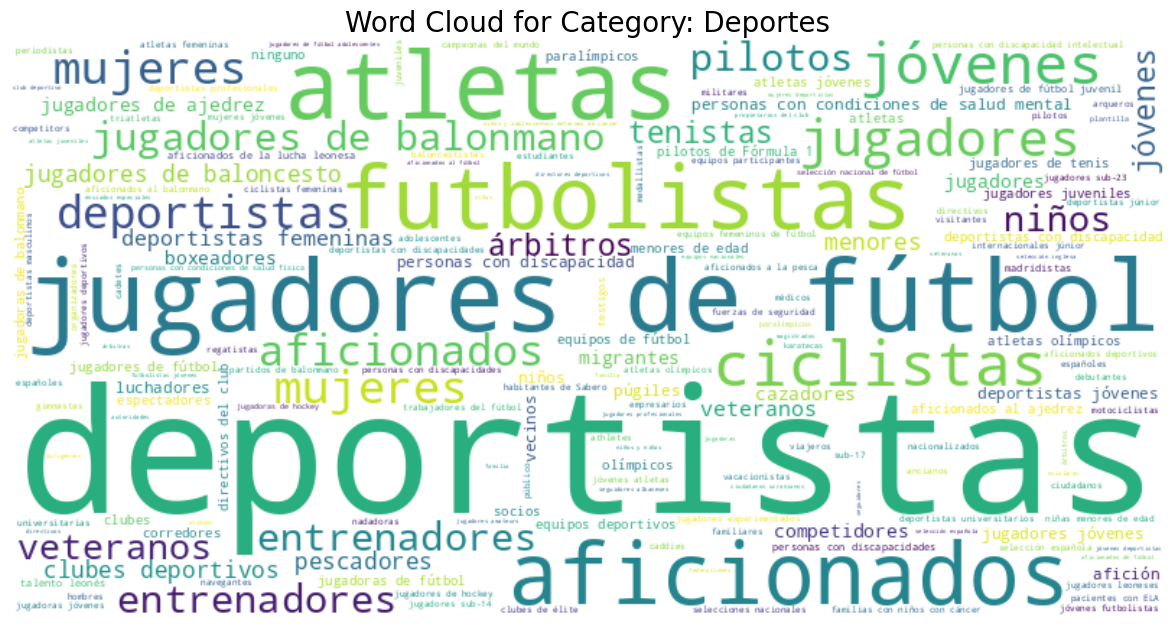

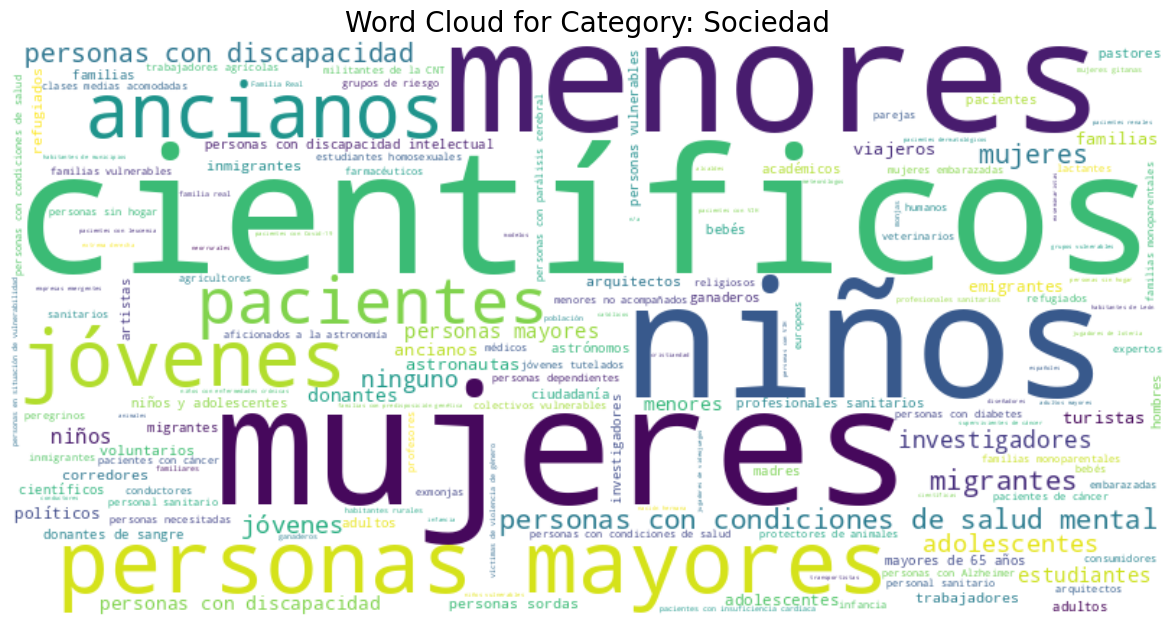

In [34]:
# Define a function to generate word clouds from frequencies
def generate_wordcloud_from_frequencies(frequencies, category_name):
    # Create a word cloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(frequencies)
    
    # Display the generated image
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Category: {category_name.capitalize()}', fontsize=20)
    plt.show()

# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [17]:
df.head()

,url,title,subtitle,author,category,publication_date,updated_date,keywords,image,location,...,numero_protagonistas,numero_protagonistas_femeninos,numero_protagonistas_masculinos,numero_sujetos_secundarios,numero_sujetos_secundarios_femeninos,numero_sujetos_secundarios_masculinos,main_keywords,population_groups,gender_ratio_principales,gender_ratio_secundario
0,https://www.diariodeleon.es/deportes/240830/16...,Lucha leonesa: Valencia de Don Juan acoge hoy ...,La localidad leonesa de Valencia de Don Juan d...,Redacción,Deportes,2024-08-30T21:40:09Z,2024-08-30T21:40:09Z,"[Corros, Liga de Verano, Lucha leonesa, Trofeo...",https://imagenes.diariodeleon.es/files/article...,León,...,0,0,0,0,0,0,"deporte, evento, tradición",,NaN,NaN
1,https://www.diariodeleon.es/deportes/240830/16...,"Paralímpicos: Sara Aller, eliminada en competi...",La leonesa Sara Aller acumuló su tercera derro...,Redacción,Deportes,2024-08-30T21:39:48Z,2024-08-30T21:39:48Z,[],https://imagenes.diariodeleon.es/files/article...,León,...,2,2,0,0,0,0,"boccia, derrota, competición",paralímpicos,0.0,NaN
2,https://www.diariodeleon.es/deportes/240830/16...,El Ademar va a dar el golpe,Dani Gordo cree que su equipo llega preparado ...,Pablo Rioja,Deportes,2024-08-30T21:39:06Z,2024-08-30T21:39:06Z,"[Ademar, León]",https://imagenes.diariodeleon.es/files/article...,León,...,1,0,1,0,0,0,"deporte, competición, eliminatoria",,1.0,NaN
3,https://www.diariodeleon.es/deportes/240830/16...,La Cultural ficha a Chacón antes de medirse al...,El equipo leonés se estrena a domicilio El ext...,Ángel Fraguas,Deportes,2024-08-30T21:38:27Z,2024-08-30T21:38:27Z,"[Cultural y Deportiva Leonesa, León, SD Ponfer...",https://imagenes.diariodeleon.es/files/article...,León,...,3,0,3,1,0,1,"fútbol, fichajes, cesión",,1.0,1.0
4,https://www.diariodeleon.es/bierzo/240830/1606...,Vinicultura: Asaja pide a la DO Bierzo que com...,El Bocyl publica que resolución que autoriza e...,Redacción,El Bierzo,2024-08-30T20:49:34Z,2024-08-30T20:49:34Z,"[ASAJA, Bocyl, Castilla y León, DO Bierzo, León]",https://imagenes.diariodeleon.es/files/article...,Ponferrada,...,4,0,0,0,0,0,"vinicultura, regulación, uva",agricultores,NaN,NaN


In [35]:
import ast
import matplotlib.pyplot as plt
df['main_keywords'] = df['main_keywords'].apply(lambda x: x.split(',') if x else [])
# Step 2: Explode the 'keywords' column
df_exploded = df.explode('main_keywords')
df_exploded = df_exploded[df_exploded['main_keywords'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold main_keywords per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['main_keywords'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


/tmp/ipykernel_17687/2911421574.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_exploded.fillna('', inplace=True)


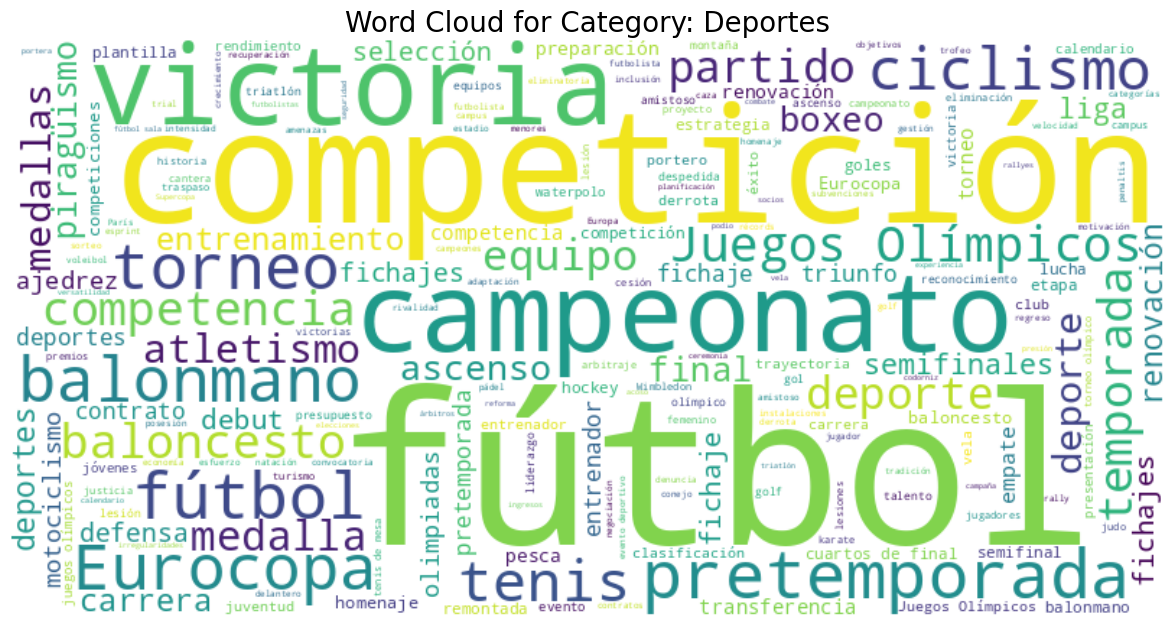

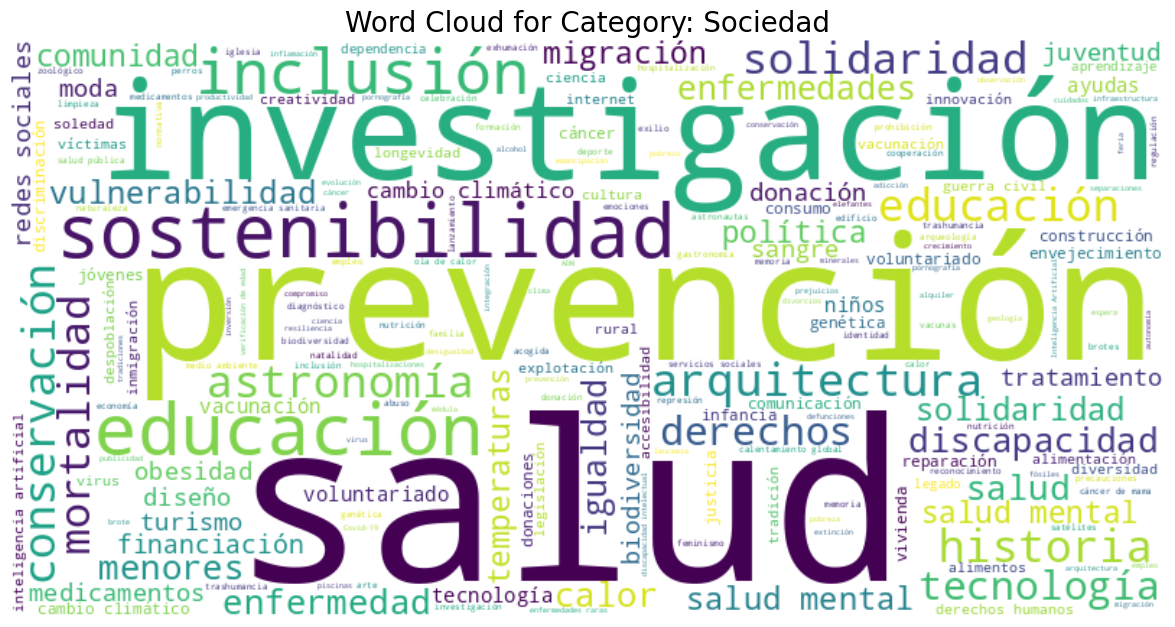

In [36]:
# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [37]:
import ast
import matplotlib.pyplot as plt
# Step 2: Explode the 'keywords' column
df['population_groups'] = df['population_groups'].apply(lambda x: x.split(',') if x else [])
df_exploded = df.explode('population_groups')
df_exploded = df_exploded[df_exploded['population_groups'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold population_groups per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['population_groups'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


/tmp/ipykernel_17687/2736454004.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_exploded.fillna('', inplace=True)


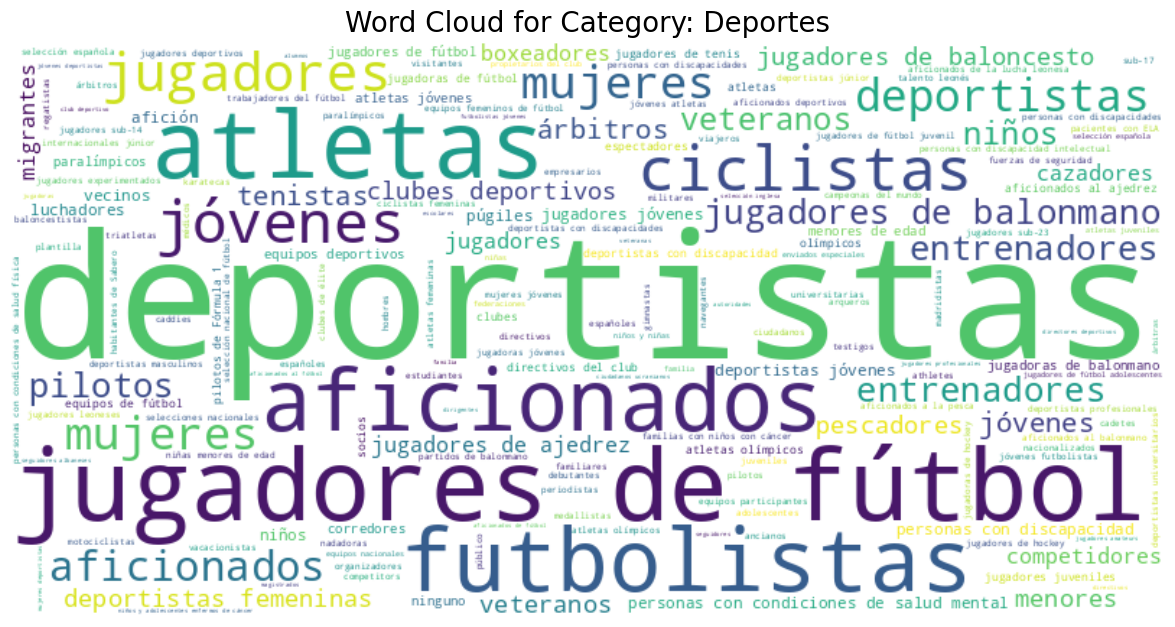

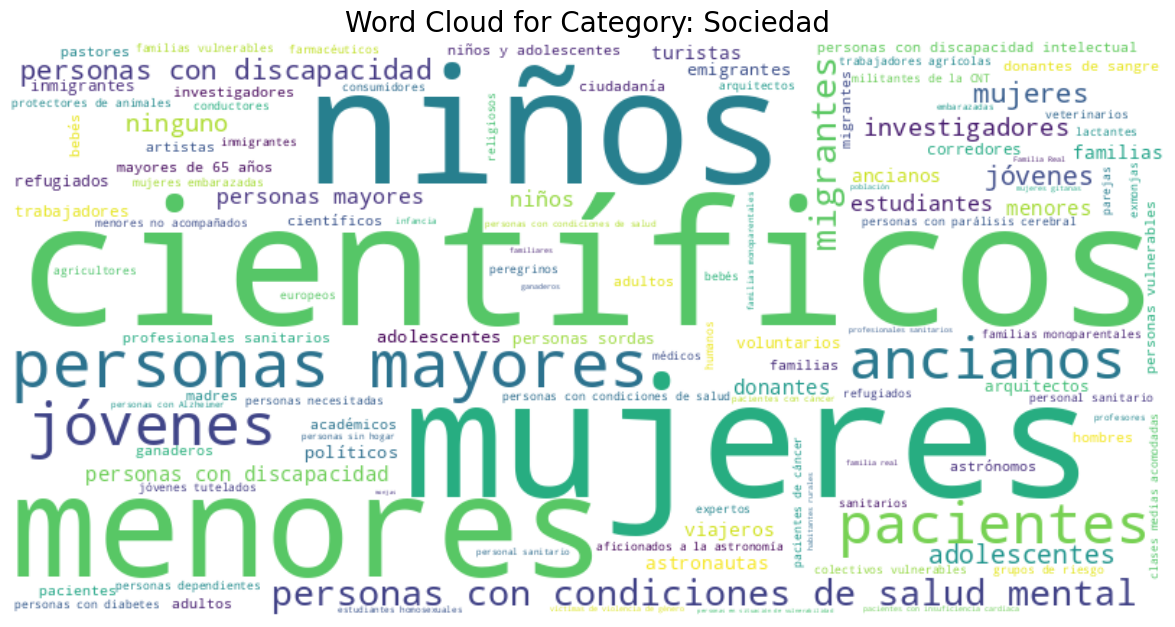

In [38]:
# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [41]:
df.to_excel('analisis_noticias.xlsx')

In [40]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-1.1.0-py3-none-any.whl.metadata (1.8 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-1.1.0-py3-none-any.whl (4.7 kB)


In [47]:
author_df.to_excel('analisis_noticias_por_autor.xlsx')